In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import copy
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [2]:
# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create dataloaders
batch_size = 128
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

In [3]:
# CIFAR-10 classes
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

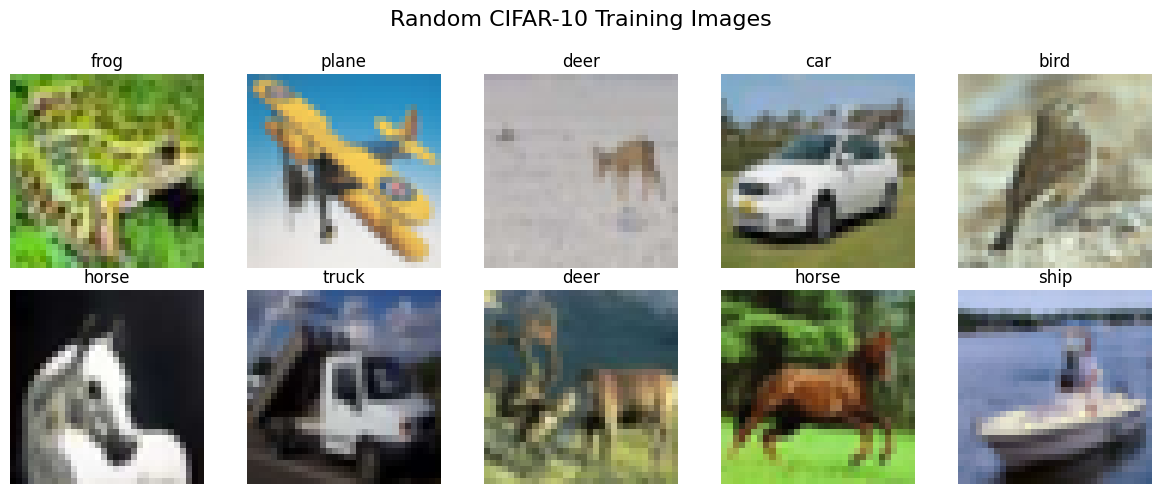

In [4]:
# Unnormalize and convert to numpy
def imshow_individual(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))  # C x H x W -> H x W x C
    return npimg

# Get a batch of training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Plot 10 images (5 per row)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Random CIFAR-10 Training Images", fontsize=16)

for idx in range(10):
    row = idx // 5
    col = idx % 5
    ax = axes[row, col]
    ax.imshow(imshow_individual(images[idx]))
    ax.set_title(classes[labels[idx]])
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Leave space for suptitle
plt.show()


In [5]:
class StudentCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(StudentCNN, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # Block 1: 32x32x3 -> 16x16x32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
            
            # Block 2: 16x16x32 -> 8x8x64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
            
            # Block 3: 8x8x64 -> 4x4x128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.5),
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Create model and count parameters
student_model = StudentCNN().to(device)
total_params = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(p.numel() for p in student_model.parameters() if p.requires_grad)

print(f'Total parameters in StudentCNN: {total_params:,}')
print(f'Trainable parameters in StudentCNN: {trainable_params:,}')
print(f'StudentCNN Model size: ~{total_params * 4 / 1024 / 1024:.2f} MB')

Total parameters in StudentCNN: 102,602
Trainable parameters in StudentCNN: 102,602
StudentCNN Model size: ~0.39 MB


In [6]:
# Evaluation function
def evaluate_model(model, test_loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
    
    test_loss = running_loss / len(test_loader.dataset)
    test_acc = running_corrects.double() / len(test_loader.dataset)
    return test_loss, test_acc.cpu()

In [7]:
# Training function
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=20):
    train_loss_history = []
    train_acc_history = []
    test_loss_history = []
    test_acc_history = []
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc.cpu())
        
        # Evaluate on test set
        test_loss, test_acc = evaluate_model(model, test_loader, criterion)
        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc)
        
        # Save best model
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_wts = copy.deepcopy(model.state_dict())
        
        print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, train_loss_history, train_acc_history, test_loss_history, test_acc_history

In [8]:
# Train the Student CNN
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(student_model.parameters(), lr=0.001)

start_time = time.time()
student_model, train_loss, train_acc, test_loss, test_acc = train_model(
    student_model, trainloader, testloader, criterion, optimizer, num_epochs=20
)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

Epoch 1/20: 100%|██████████| 391/391 [00:04<00:00, 88.10it/s] 


Epoch 1/20 - Train Loss: 1.9930, Train Acc: 0.2389, Test Loss: 1.7041, Test Acc: 0.3705


Epoch 2/20: 100%|██████████| 391/391 [00:04<00:00, 92.62it/s]


Epoch 2/20 - Train Loss: 1.7990, Train Acc: 0.3115, Test Loss: 1.5735, Test Acc: 0.4055


Epoch 3/20: 100%|██████████| 391/391 [00:04<00:00, 78.47it/s]


...

Epoch 18/20 - Train Loss: 1.3058, Train Acc: 0.5264, Test Loss: 1.1003, Test Acc: 0.6030


Epoch 19/20: 100%|██████████| 391/391 [00:04<00:00, 92.90it/s]


Epoch 19/20 - Train Loss: 1.2894, Train Acc: 0.5311, Test Loss: 1.0798, Test Acc: 0.6182


Epoch 20/20: 100%|██████████| 391/391 [00:04<00:00, 94.56it/s]


Epoch 20/20 - Train Loss: 1.2777, Train Acc: 0.5356, Test Loss: 1.0709, Test Acc: 0.6223
Training completed in 104.26 seconds


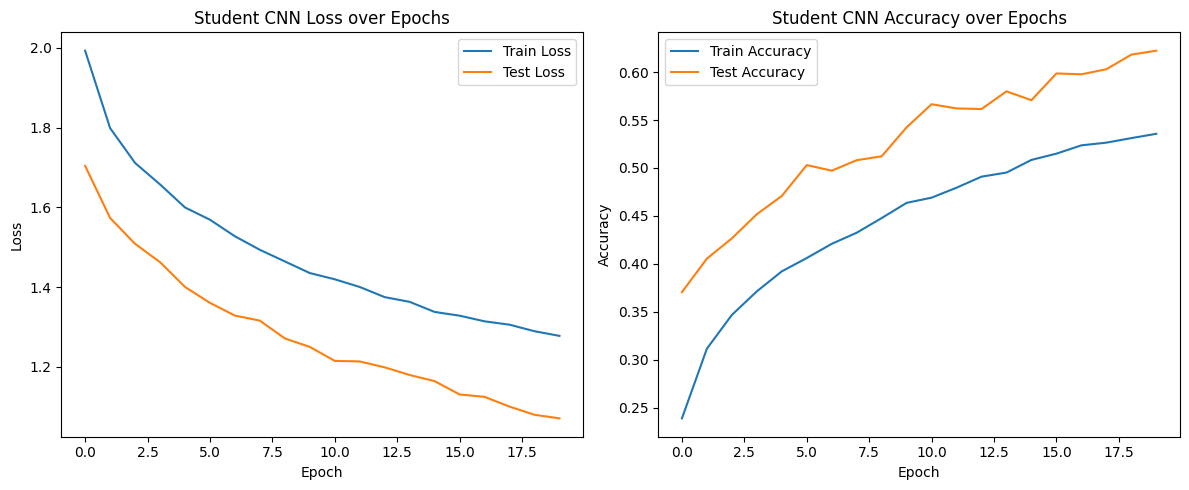

In [9]:
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.title('Student CNN Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([t.numpy() for t in train_acc], label='Train Accuracy')
plt.plot([t.numpy() for t in test_acc], label='Test Accuracy')
plt.title('Student CNN Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Load pre-trained models
from torchvision import models

def get_pretrained_model(model_name):
    if model_name == 'resnet18':
        model = models.resnet18(pretrained=True)
        # Replace the last layer
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, 10)
    elif model_name == 'vgg16':
        model = models.vgg16(pretrained=True)
        # Replace the last layer
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_ftrs, 10)
    else:
        raise ValueError("Unknown model name")
    
    return model.to(device)

# Initialize models
resnet18 = get_pretrained_model('resnet18')
vgg16 = get_pretrained_model('vgg16')

/mnt/A04C91DC4C91AE12/Thesis-works/codes/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/A04C91DC4C91AE12/Thesis-works/codes/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/hci-lab/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:14<00:00, 3.13MB/s]
/mnt/A04C91DC4C91AE12/Thesis-works/codes/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
# Fine-tuning function
def fine_tune_model(model, train_loader, test_loader, model_name, num_epochs=10):
    # Freeze all layers except the last one
    for name, param in model.named_parameters():
        if 'fc' in name or 'classifier.6' in name:  # Unfreeze last layer
            param.requires_grad = True
        else:
            param.requires_grad = False
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)
    
    print(f"\nFine-tuning {model_name}...")
    start_time = time.time()
    model, train_loss, train_acc, test_loss, test_acc = train_model(
        model, train_loader, test_loader, criterion, optimizer, num_epochs=num_epochs
    )
    training_time = time.time() - start_time
    print(f"Fine-tuning completed in {training_time:.2f} seconds")
    
    # Plot results
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(test_loss, label='Test Loss')
    plt.title(f'{model_name} Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot([t.numpy() for t in train_acc], label='Train Accuracy')
    plt.plot([t.numpy() for t in test_acc], label='Test Accuracy')
    plt.title(f'{model_name} Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return model


Fine-tuning ResNet18...


Epoch 1/10: 100%|██████████| 391/391 [00:04<00:00, 89.05it/s]


Epoch 1/10 - Train Loss: 2.1786, Train Acc: 0.2162, Test Loss: 1.9596, Test Acc: 0.3216


Epoch 2/10: 100%|██████████| 391/391 [00:04<00:00, 95.53it/s] 


Epoch 2/10 - Train Loss: 1.8517, Train Acc: 0.3597, Test Loss: 1.8036, Test Acc: 0.3837


...

Epoch 8/10 - Train Loss: 1.5916, Train Acc: 0.4525, Test Loss: 1.6148, Test Acc: 0.4469


Epoch 9/10: 100%|██████████| 391/391 [00:04<00:00, 91.13it/s]


Epoch 9/10 - Train Loss: 1.5801, Train Acc: 0.4536, Test Loss: 1.6126, Test Acc: 0.4494


Epoch 10/10: 100%|██████████| 391/391 [00:04<00:00, 95.09it/s]


Epoch 10/10 - Train Loss: 1.5728, Train Acc: 0.4592, Test Loss: 1.6004, Test Acc: 0.4529
Fine-tuning completed in 50.34 seconds


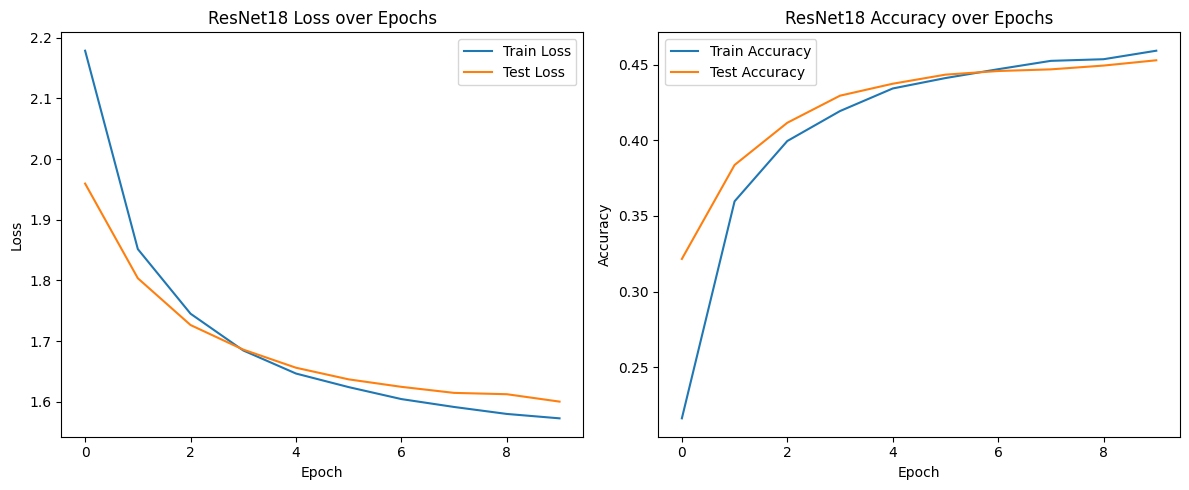


Fine-tuning VGG16...


Epoch 1/10: 100%|██████████| 391/391 [00:06<00:00, 58.51it/s]


Epoch 1/10 - Train Loss: 1.5194, Train Acc: 0.4638, Test Loss: 1.2312, Test Acc: 0.5751


Epoch 2/10: 100%|██████████| 391/391 [00:06<00:00, 57.12it/s]


Epoch 2/10 - Train Loss: 1.2648, Train Acc: 0.5556, Test Loss: 1.1628, Test Acc: 0.6005


...

Epoch 8/10 - Train Loss: 1.1093, Train Acc: 0.6115, Test Loss: 1.0788, Test Acc: 0.6278


Epoch 9/10: 100%|██████████| 391/391 [00:06<00:00, 56.21it/s]


Epoch 9/10 - Train Loss: 1.1036, Train Acc: 0.6127, Test Loss: 1.0779, Test Acc: 0.6233


Epoch 10/10: 100%|██████████| 391/391 [00:06<00:00, 56.28it/s]


Epoch 10/10 - Train Loss: 1.1013, Train Acc: 0.6130, Test Loss: 1.0727, Test Acc: 0.6290
Fine-tuning completed in 83.37 seconds


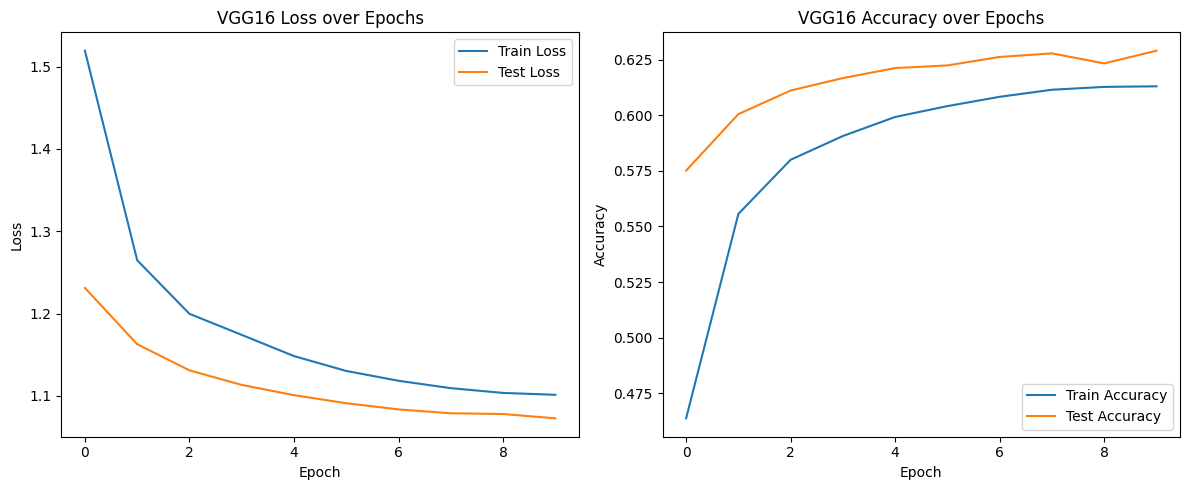

In [12]:
# Fine-tune both models
resnet18 = fine_tune_model(resnet18, trainloader, testloader, 'ResNet18')
vgg16 = fine_tune_model(vgg16, trainloader, testloader, 'VGG16')

In [13]:
# Knowledge Distillation Loss
class DistillationLoss(nn.Module):
    def __init__(self, temperature=3.0, alpha=0.7):
        super().__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss()
        self.kl_loss = nn.KLDivLoss(reduction='batchmean')
        
    def forward(self, student_logits, teacher1_logits, teacher2_logits, labels):
        # Hard target loss (standard cross-entropy)
        hard_loss = self.ce_loss(student_logits, labels)
        
        # Soft target loss (average of KL divergences from both teachers)
        soft_loss1 = self.kl_loss(
            nn.functional.log_softmax(student_logits / self.temperature, dim=1),
            nn.functional.softmax(teacher1_logits / self.temperature, dim=1)
        )
        soft_loss2 = self.kl_loss(
            nn.functional.log_softmax(student_logits / self.temperature, dim=1),
            nn.functional.softmax(teacher2_logits / self.temperature, dim=1)
        )
        soft_loss = (soft_loss1 + soft_loss2) / 2
        
        # Combined loss
        return self.alpha * hard_loss + (1 - self.alpha) * (self.temperature ** 2) * soft_loss


In [14]:
# Knowledge Distillation function
def distill_knowledge(student, teacher1, teacher2, train_loader, test_loader, num_epochs=20):
    # Initialize a fresh student model
    student = StudentCNN().to(device)
    
    # Set teachers to eval mode
    teacher1.eval()
    teacher2.eval()
    
    # Loss and optimizer
    criterion = DistillationLoss(temperature=3.0, alpha=0.7)
    optimizer = optim.Adam(student.parameters(), lr=0.001)
    
    train_loss_history = []
    train_acc_history = []
    test_loss_history = []
    test_acc_history = []
    
    for epoch in range(num_epochs):
        student.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in tqdm(train_loader, desc=f'Distillation Epoch {epoch+1}/{num_epochs}'):
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Get teacher predictions
            with torch.no_grad():
                teacher1_logits = teacher1(inputs)
                teacher2_logits = teacher2(inputs)
            
            # Student forward pass
            optimizer.zero_grad()
            student_logits = student(inputs)
            
            # Calculate distillation loss
            loss = criterion(student_logits, teacher1_logits, teacher2_logits, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            # Statistics
            _, preds = torch.max(student_logits, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        
        # Epoch statistics
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc.cpu())
        
        # Evaluate on test set
        test_loss, test_acc = evaluate_model(student, test_loader, nn.CrossEntropyLoss())
        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')
    
    return student, train_loss_history, train_acc_history, test_loss_history, test_acc_history

In [16]:
# Perform knowledge distillation
print("\nStarting Knowledge Distillation...")
start_time = time.time()
distilled_cnn, d_train_loss, d_train_acc, d_test_loss, d_test_acc = distill_knowledge(
    student_model, resnet18, vgg16, trainloader, testloader, num_epochs=50
)
distillation_time = time.time() - start_time
print(f"Distillation completed in {distillation_time:.2f} seconds")


Starting Knowledge Distillation...


Distillation Epoch 1/50: 100%|██████████| 391/391 [00:09<00:00, 39.79it/s]


Epoch 1/50 - Train Loss: 1.8048, Train Acc: 0.2461, Test Loss: 1.6760, Test Acc: 0.3848


Distillation Epoch 2/50: 100%|██████████| 391/391 [00:09<00:00, 39.59it/s]


Epoch 2/50 - Train Loss: 1.6363, Train Acc: 0.3136, Test Loss: 1.6069, Test Acc: 0.4210


...

Epoch 48/50 - Train Loss: 1.1676, Train Acc: 0.5991, Test Loss: 0.9757, Test Acc: 0.6892


Distillation Epoch 49/50: 100%|██████████| 391/391 [00:10<00:00, 38.81it/s]


Epoch 49/50 - Train Loss: 1.1667, Train Acc: 0.6002, Test Loss: 0.9804, Test Acc: 0.6892


Distillation Epoch 50/50: 100%|██████████| 391/391 [00:10<00:00, 38.92it/s]


Epoch 50/50 - Train Loss: 1.1628, Train Acc: 0.6011, Test Loss: 0.9749, Test Acc: 0.6981
Distillation completed in 543.91 seconds


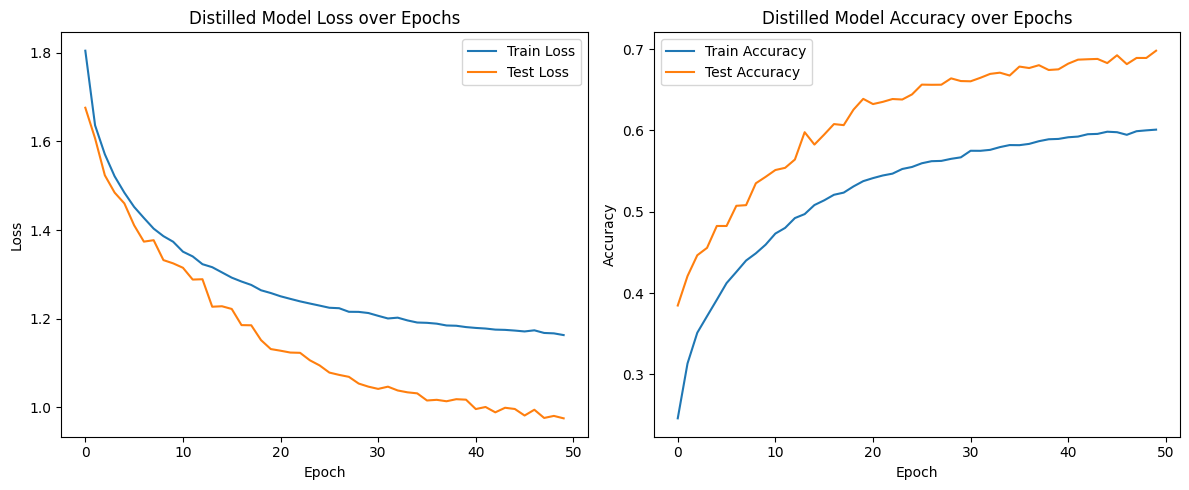

In [17]:
# Plot distillation results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(d_train_loss, label='Train Loss')
plt.plot(d_test_loss, label='Test Loss')
plt.title('Distilled Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([t.numpy() for t in d_train_acc], label='Train Accuracy')
plt.plot([t.numpy() for t in d_test_acc], label='Test Accuracy')
plt.title('Distilled Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


Distilled Student CNN Performance:


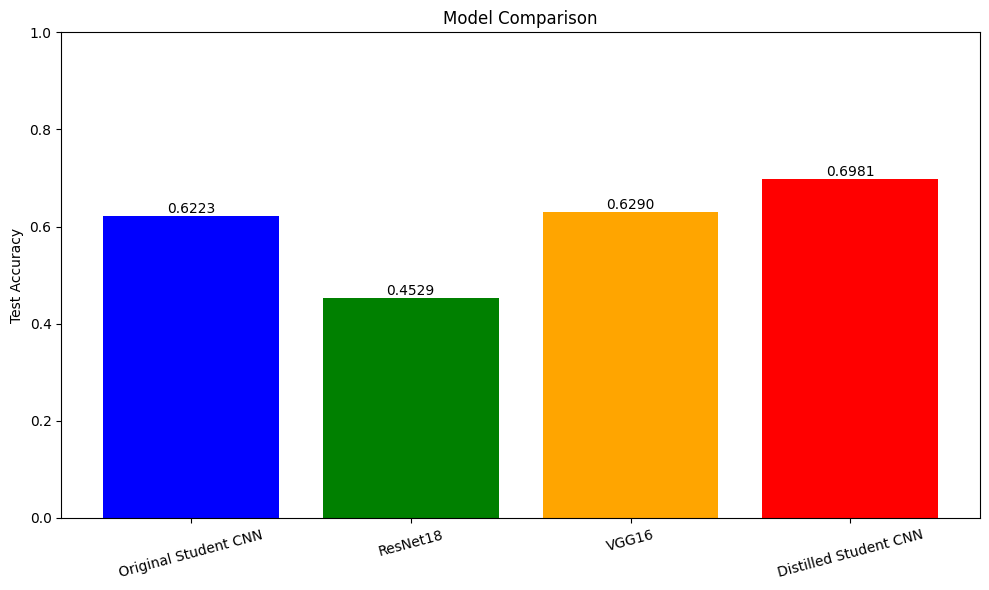

In [18]:
# Evaluate distilled model
print("\nDistilled Student CNN Performance:")

# Evaluate all models on test set
def get_model_accuracy(model, test_loader):
    _, acc = evaluate_model(model, test_loader, nn.CrossEntropyLoss())
    return acc

original_acc = get_model_accuracy(student_model, testloader)
resnet_acc = get_model_accuracy(resnet18, testloader)
vgg_acc = get_model_accuracy(vgg16, testloader)
distilled_acc = get_model_accuracy(distilled_cnn, testloader)

# Plot comparison
plt.figure(figsize=(10, 6))
models = ['Original Student CNN', 'ResNet18', 'VGG16', 'Distilled Student CNN']
accuracies = [original_acc, resnet_acc, vgg_acc, distilled_acc]
colors = ['blue', 'green', 'orange', 'red']

bars = plt.bar(models, accuracies, color=colors)
plt.ylabel('Test Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)


# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [19]:
# Print model complexity analysis
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

student_cnn_parameter, student_cnn_trainable = count_parameters(student_model)
resnet18_params, resnet18_trainable = count_parameters(resnet18)
vgg16_params, vgg16_trainable = count_parameters(vgg16)

print("\nModel Complexity Analysis:")
print("--------------------------------------------------")
print("Student CNN:")
print(f"  Total parameters: {student_cnn_parameter}")
print(f"  Trainable parameters: {student_cnn_trainable}")
print(f"  Model size: ~{student_cnn_parameter * 4 / (1024 * 1024):.2f} MB")

print("\nResNet18:")
print(f"  Total parameters: {resnet18_params}")
print(f"  Trainable parameters: {resnet18_trainable}")
print(f"  Model size: ~{resnet18_params * 4 / (1024 * 1024):.2f} MB")

print("\nVGG16:")
print(f"  Total parameters: {vgg16_params}")
print(f"  Trainable parameters: {vgg16_trainable}")
print(f"  Model size: ~{vgg16_params * 4 / (1024 * 1024):.2f} MB")

# Print performance analysis
print("\nPerformance Analysis:")
print("--------------------------------------------------")
print(f"Student CNN (Original): {original_acc:.2f}%")
print(f"ResNet18 Teacher: {resnet_acc:.2f}%")
print(f"VGG16 Teacher: {vgg_acc:.2f}%")
print(f"Student CNN (Distilled): {distilled_acc:.2f}%")

print("\nKnowledge Distillation Results:")
print("--------------------------------------------------")
print(f"Original Student: {original_acc:.2f}%")
print(f"Distilled Student: {distilled_acc:.2f}%")
print(f"Improvement: {distilled_acc - original_acc:.2f}%")


Model Complexity Analysis:
--------------------------------------------------
Student CNN:
  Total parameters: 102602
  Trainable parameters: 102602
  Model size: ~0.39 MB

ResNet18:
  Total parameters: 11181642
  Trainable parameters: 5130
  Model size: ~42.65 MB

VGG16:
  Total parameters: 134301514
  Trainable parameters: 40970
  Model size: ~512.32 MB

Performance Analysis:
--------------------------------------------------
Student CNN (Original): 0.62%
ResNet18 Teacher: 0.45%
VGG16 Teacher: 0.63%
Student CNN (Distilled): 0.70%

Knowledge Distillation Results:
--------------------------------------------------
Original Student: 0.62%
Distilled Student: 0.70%
Improvement: 0.08%
